In [1]:
import pandas as pd
import numpy as np
import datetime as dt 
import yfinance as yf

In [2]:
start = dt.datetime(2013,1,1)
end = dt.datetime(2023,1,1)
stk_data = yf.download("RELIANCE.NS", start=start, end=end)

[*********************100%***********************]  1 of 1 completed


In [3]:
stk_data

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2013-01-01,176.018600,177.253899,175.683602,176.709535,6831351
2013-01-02,177.536530,179.221978,176.405928,176.709522,13441898
2013-01-03,180.216507,180.478214,176.835156,177.672632,17266808
2013-01-04,180.446793,181.022562,178.709017,180.457261,13306377
2013-01-07,179.347626,182.362573,178.342643,181.252908,15307180
...,...,...,...,...,...
2022-12-26,1152.220215,1160.414342,1137.772122,1147.974874,5990242
2022-12-27,1161.646851,1163.518428,1148.203010,1154.936341,5763271


In [4]:
dataset = stk_data[["Close"]].copy()
dataset.columns

MultiIndex([('Close', 'RELIANCE.NS')],
           names=['Price', 'Ticker'])

In [5]:
dataset

Price,Close
Ticker,RELIANCE.NS
Date,
2013-01-01,176.018600
2013-01-02,177.536530
2013-01-03,180.216507
2013-01-04,180.446793
2013-01-07,179.347626
...,...
2022-12-26,1152.220215
2022-12-27,1161.646851


In [6]:
#perform ADF test for checking stationarity.
from statsmodels.tsa.stattools import adfuller

result = adfuller(dataset['Close'])
print("ADF statistic:", result[0])
print("p-value:", result[1])

ADF statistic: 0.02540766473333492
p-value: 0.9605835193171385


In [7]:
#Perform Log since data is non stationarity
dataset['Log_Close'] = np.log(dataset['Close'])

In [8]:
#perform difference for log_close value
dataset['Log_Diff_Close'] = dataset['Log_Close'].diff()

In [9]:
#Dropping null value
dataset.dropna(inplace=True)

In [10]:
#ADF test
from statsmodels.tsa.stattools import adfuller

result = adfuller(dataset["Log_Diff_Close"])
print("ADF statistic:", result[0])
print("p-value:", result[1])

ADF statistic: -15.108289513220097
p-value: 7.7620368098222125e-28


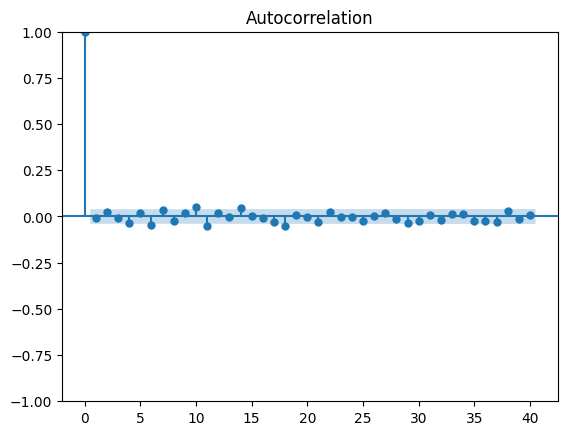

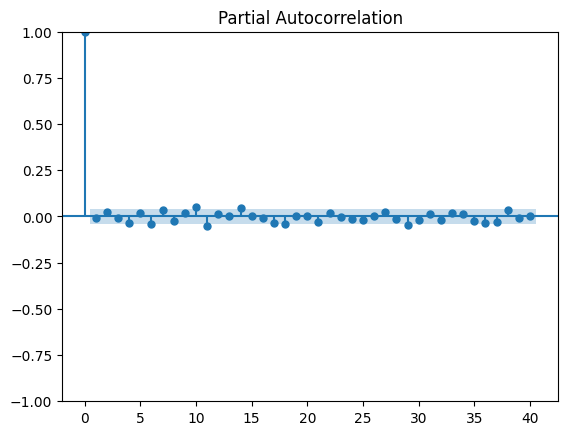

In [14]:
#plot acf and pcf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plot_acf(dataset["Log_Diff_Close"], lags=40)
plot_pacf(dataset["Log_Diff_Close"], lags=40)
plt.show()

In [23]:
#Split train and test data
series = dataset['Log_Diff_Close']
train_size = int(len(series) * 0.8)

train = series[:train_size]
test  = series[train_size:]

In [24]:
train

Date
2013-01-02    0.008587
2013-01-03    0.014983
2013-01-04    0.001277
2013-01-07   -0.006110
2013-01-08   -0.006971
                ...   
2020-12-29   -0.006636
2020-12-30    0.002735
2020-12-31   -0.005125
2021-01-01    0.001108
2021-01-04    0.001684
Name: Log_Diff_Close, Length: 1973, dtype: float64

In [25]:
test

Date
2021-01-05   -0.012510
2021-01-06   -0.026726
2021-01-07   -0.001621
2021-01-08    0.011730
2021-01-11   -0.019030
                ...   
2022-12-26    0.008694
2022-12-27    0.008148
2022-12-28   -0.000098
2022-12-29   -0.000452
2022-12-30    0.001532
Name: Log_Diff_Close, Length: 494, dtype: float64

In [28]:
#Model Creation
from sklearn.metrics import mean_squared_error
trends=['n','t','c','ct']
lags=[1,2,3,4]
from statsmodels.tsa.ar_model import AutoReg
for i in lags:
    for td in trends:
        model = AutoReg(train, lags=i,trend=td)
        model_fit = model.fit()
        # make prediction
        y_pred= model_fit.predict(len(train), len(series)-1)
        #print(y_pred)
        #mse=mean_squared_error(y_test,y_pred,squared=False)
        from stockFunctions import rmsemape
        print("Lag={},Trend={}".format(i,td))
        rmsemape(y_test,y_pred)
        print("************")

C:\Users\PAVAN\anaconda3\envs\MYSpace\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\PAVAN\anaconda3\envs\MYSpace\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\PAVAN\anaconda3\envs\MYSpace\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\PAVAN\anaconda3\envs\MYSpace\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit i

ModuleNotFoundError: No module named 'stockFunctions'

In [29]:
!pip install stockFunctions

ERROR: Could not find a version that satisfies the requirement stockFunctions (from versions: none)
ERROR: No matching distribution found for stockFunctions
